In [2]:
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


I0000 00:00:1767720296.584176      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767720296.588086      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
from keras.utils import to_categorical
from keras.preprocessing.image import load_img
from keras.models import Sequential
from keras. layers import Dense, Dropout, Flatten, MaxPooling2D,Conv2D
import os
import pandas as pd
import numpy as np

In [4]:
Train_Dir='/kaggle/input/face-expression-recognition-dataset/images/train/'
Test_Dir='/kaggle/input/face-expression-recognition-dataset/images/validation/'

In [5]:
def createdataframe(dir):
    image_path=[]
    labels=[]
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_path.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label,'Completed')

    return image_path,labels
    

In [6]:
train=pd.DataFrame()
train['image'],train['label']=createdataframe(Train_Dir)

surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed


In [7]:
print(train['image'][0])

/kaggle/input/face-expression-recognition-dataset/images/train/surprise/30778.jpg


In [8]:
test=pd.DataFrame()
test['image'],test['label']=createdataframe(Test_Dir)

surprise Completed
fear Completed
angry Completed
neutral Completed
sad Completed
disgust Completed
happy Completed


In [9]:
test.head(5)

,image,label
0,/kaggle/input/face-expression-recognition-data...,surprise
1,/kaggle/input/face-expression-recognition-data...,surprise
2,/kaggle/input/face-expression-recognition-data...,surprise
3,/kaggle/input/face-expression-recognition-data...,surprise
4,/kaggle/input/face-expression-recognition-data...,surprise


In [10]:
test['image'][50]

'/kaggle/input/face-expression-recognition-dataset/images/validation/surprise/25229.jpg'

In [11]:
from tqdm.notebook import tqdm

In [12]:
def preprocessing(images):
    features=[]
    for image in tqdm(images):
        img=load_img(image,color_mode='grayscale')
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features=features.reshape(len(features),48,48,1)
    return features

In [13]:
train_p=preprocessing(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

In [14]:
test_p=preprocessing(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [30]:
x_train=train_p/255.0
x_test=test_p/255.0

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
label_encoder=LabelEncoder()
y_train=label_encoder.fit_transform(train['label'])
y_test=label_encoder.transform(test['label'])

In [33]:
y_train=to_categorical(y_train,num_classes=7)
y_test=to_categorical(y_test,num_classes=7)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau,TensorBoard

In [42]:
early_stoping=EarlyStopping(
    monitor='val_loss',
    patience=15,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0
)

In [56]:
rlearning=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    mode='auto',
    min_delta=0.0001,
    cooldown=0
)

In [44]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',    
    monitor='val_loss',              
    verbose=1,                       
    save_best_only=True,             
    save_weights_only=False,  
    mode='min',                      
    save_freq='epoch'               
)

In [45]:
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard=TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=False,
    write_steps_per_second=False,
    update_freq='epoch',
    profile_batch=0,
    embeddings_freq=1,
    embeddings_metadata=None
)

In [46]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import BatchNormalization

In [75]:
from sklearn.utils import class_weight
import numpy as np

# 1. Identify all unique labels in your training set
unique_labels = np.unique(train['label'])

# 2. Calculate the weights
# 'balanced' automatically gives higher weight to classes with fewer images
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=train['label']
)

# 3. Create a dictionary that Keras can understand (index: weight)
class_weights = dict(enumerate(weights))

print("Calculated Class Weights:", class_weights)

Calculated Class Weights: {0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


In [76]:
with strategy.scope():
    model=Sequential()

    model.add(RandomFlip("horizontal", input_shape=(48, 48, 1)))
    model.add(RandomRotation(0.1))
    model.add(RandomZoom(0.1))
    
    model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=(48,48,1)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(.4))
    
    model.add(Conv2D(256,kernel_size=(3,3),activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(.4))
    
    model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(.4))

    model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(.4))
    
    model.add(Flatten())
    
    model.add(Dense(512,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(.4))
    model.add(Dense(256,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(.3))
    model.add(Dense(7,activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [77]:
model.fit(
    x=x_train, 
    y=y_train, 
    batch_size=128, 
    epochs=150, 
    validation_data=(x_test, y_test), 
    callbacks=[checkpoint, rlearning,early_stoping,tensorboard],
    class_weight=class_weights
)

Epoch 1/150
INFO:tensorflow:Collective all_reduce tensors: 26 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1767726768.001701      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_12_1/dropout_63_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1541 - loss: 2.5670
Epoch 1: val_loss did not improve from 1.00133
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.1541 - loss: 2.5650 - val_accuracy: 0.0338 - val_loss: 2.2951 - learning_rate: 0.0010
Epoch 2/150
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1675 - loss: 2.0931
Epoch 2: val_loss did not improve from 1.00133
226/226 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.1676 - loss: 2.0928 - val_accuracy: 0.2437 - val_loss: 1.8464 - learning_rate: 0.0010
Epoch 3/150
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2014 - loss: 1.9371
Epoch 3: val_loss did not improve from 1.00133
226/226 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.2015 - loss: 1.9371 - val_accuracy: 0.2137 - val_loss: 1.9584 - learning_rate: 0.0010
Epoch 4/150
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2233 - loss: 1.8865
Epoch 4: val_loss did not improve from 1.00133
226/226 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step 

In [78]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the model's predictions
y_pred = model.predict(x_test)

# 2. Convert one-hot encoded data back to class indices (0 to 6)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Get the original class names from your LabelEncoder
# Based on your dataset: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
class_names = label_encoder.classes_

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


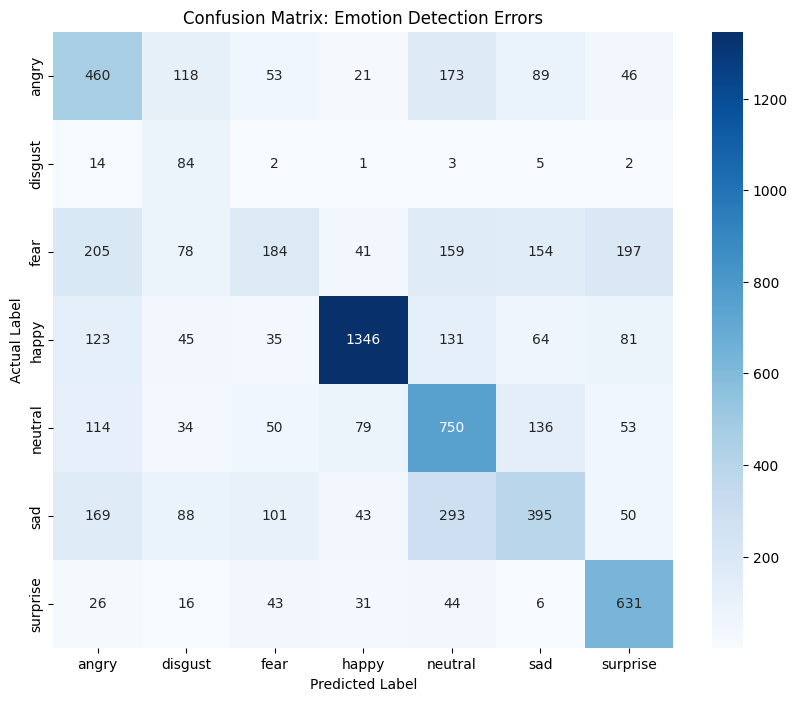

In [79]:
# Create the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot using Seaborn for better visibility
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix: Emotion Detection Errors')
plt.savefig('Confusion-metrics-withClassWeights.png')
plt.show()